# Goals for this project:

1. Get data from an archive
2. Learn how to use functions in python
2. Learn how to fit data

We will be using Fermi-LAT data on the Crab Nebula during flaring periods to investigate different fitting
algorithms and techniques. We will be fitting a gaussian and a parabola to each curve to find the peak of the
flare (when in time is the peak). Determining the peak of a flare in time is very important when using multi-wavelength observations to study an object. For example, knowing exactly when the Crab Nebula peaks in gamma-rays and comparing this peak to a longer wavelength, you can develop models on what environment that flare originated at depending on how fast the material from the flare cools down to lower energy emission (some material cools down faster than others, so this will give you a sense of what the environment is that the flare occured in, and where exactly it occured). 

# Question 1: Introduction to the Crab Nebula

What is the crab nebula? What are Crab Flares? Refer to sections 1,2, and 5 of this paper for additional information: <url> https://arxiv.org/pdf/1309.7046.pdf


The Crab Nebula is a remnant of a supernova explosion that was observed in 1054 AD. It is located in the constellation Taurus, and is one of the most studied objects in astronomy. The Crab Nebula is a pulsar wind nebula, which means that the nebula is powered by a pulsar, a rapidly rotating neutron star. The pulsar in the Crab Nebula rotates about 30 times per second and is a strong source of gamma-rays.

Crab Flares are sudden increases in the gamma-ray emission from the Crab Nebula. They are thought to be caused by the pulsar accelerating electrons to very high energies. When these electrons interact with the magnetic field in the nebula, they produce gamma-rays. The exact cause of Crab Flares is still a topic of active research.

### 1.a. The Crab Nebula and the Fermi-LAT

The Crab Nebula is a strong source of gamma-rays, which makes it an ideal target for the Fermi-LAT. The Fermi-LAT is a space-based gamma-ray telescope that has been in orbit since 2008. It is a large-area telescope that is sensitive to gamma-rays with energies between 20 MeV and 300 GeV. The Fermi-LAT has detected many flares from the Crab Nebula, which has provided valuable information about the high-energy processes that are happening in the nebula.

The Fermi-LAT is an example of a space-based gamma-ray telescope. There are also ground-based gamma-ray telescopes, such as H.E.S.S. and VERITAS, that are sensitive to gamma-rays with energies above 100 GeV. These telescopes are used to study the highest-energy gamma-rays in the universe, which are produced by some

# Question 2: Getting Data from an Archive

### 2.a.i. Download Data

Now let's get some data! If you remember from class, HEASARC is one of the NASA archives which serves the Fermi Gamma-ray space telescope. Using the following link, locate the LAT Monitored Source List Light Curves and click on that page: <url> https://fermi.gsfc.nasa.gov/ssc/data/access/ .

From here, search for the Crab Pulsar and right click on the Daily Light Curve Fits File. You will then click on "Save Link As..." and save the file to your computer. You will then be able to upload this data file to your directory on the jupyter hub (should be a .lc file).

Below, read in the fits file using the `fits.open` function and save the result as `data` (look up this function for information on how to do this). 

In [2]:
#Importing necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import scipy.constants
from astropy.io import fits

In [3]:
# Place your code here
data = fits.open('../Tables/CrabPulsar_86400.lc')

### 2.a.ii. View the table information

Next, view the headers of the fits file, which contains information about the data stored in the table. You can access the header like this: `data[1].header`  (look at the bottom of the output to find the names of the columns included in the data file.). 

In [4]:
# accessing the header of the fits file
data[1].header

XTENSION= 'BINTABLE'           / binary table extension                         
BITPIX  =                    8 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                   70 / length of dimension 1                          
NAXIS2  =                 5848 / length of dimension 2                          
PCOUNT  =                    0 / number of group parameters                     
GCOUNT  =                    1 / number of groups                               
TFIELDS =                   16 / number of table fields                         
COMMENT                                                                         
COMMENT  *** End of mandatory fields ***                                        
COMMENT                                                                         
COMMENT                                                                         
COMMENT  *** End of mandator

### 2.b. Reading in the data and assigning variable names

We will want the Flux for 100_300000 MeV energy cut, the corresponding error for those fluxes, and the time (this column is somewhat unintuitively called `STOP`). Read in the flux, flux errors, and time into your notebook and give them corresponding names. The data is stored in `data[1].data` and you access the columns by putting the name of the column in square brackets. 

As can be seen in the fits header that you printed out above, the time variable unit is seconds. Convert your time 

In [5]:
# reading in data
flux = data[1].data['FLUX_100_300000']
flux_err = data[1].data['ERROR_100_300000']
time = data[1].data['STOP']
# converting time to days
time = time/(60*60*24)

### 2.c. Plotting our archive data

Let's now plot this data we got from our first archive! Using the `plt.errorbar` function, plot your flux, flux errors, and time. Please use appropriate titles and axis labels (if you need to find the units for your flux, please look at the headers we loaded in). Choose how the data is plotted so that your plot is an accurate reflection of the data.

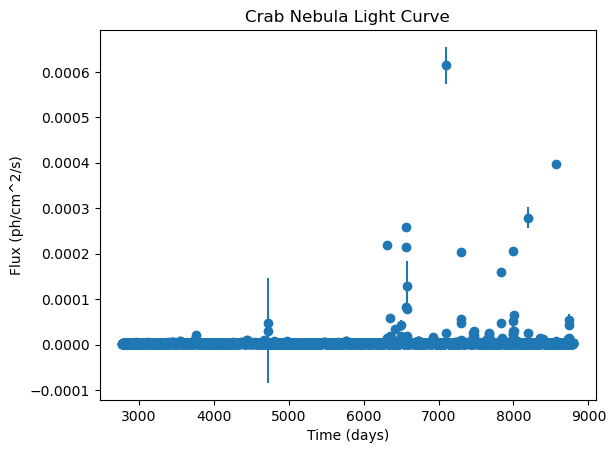

In [6]:
# plotting the data
plt.errorbar(time, flux, yerr=flux_err, fmt='o')
plt.xlabel('Time (days)')
plt.ylabel('Flux (ph/cm^2/s)')
plt.title('Crab Nebula Light Curve')
plt.show()

Now, compare your plot to the one shown on the archive page where you downloaded the file originally. Adapt your plot so that it more closely matches the one online.

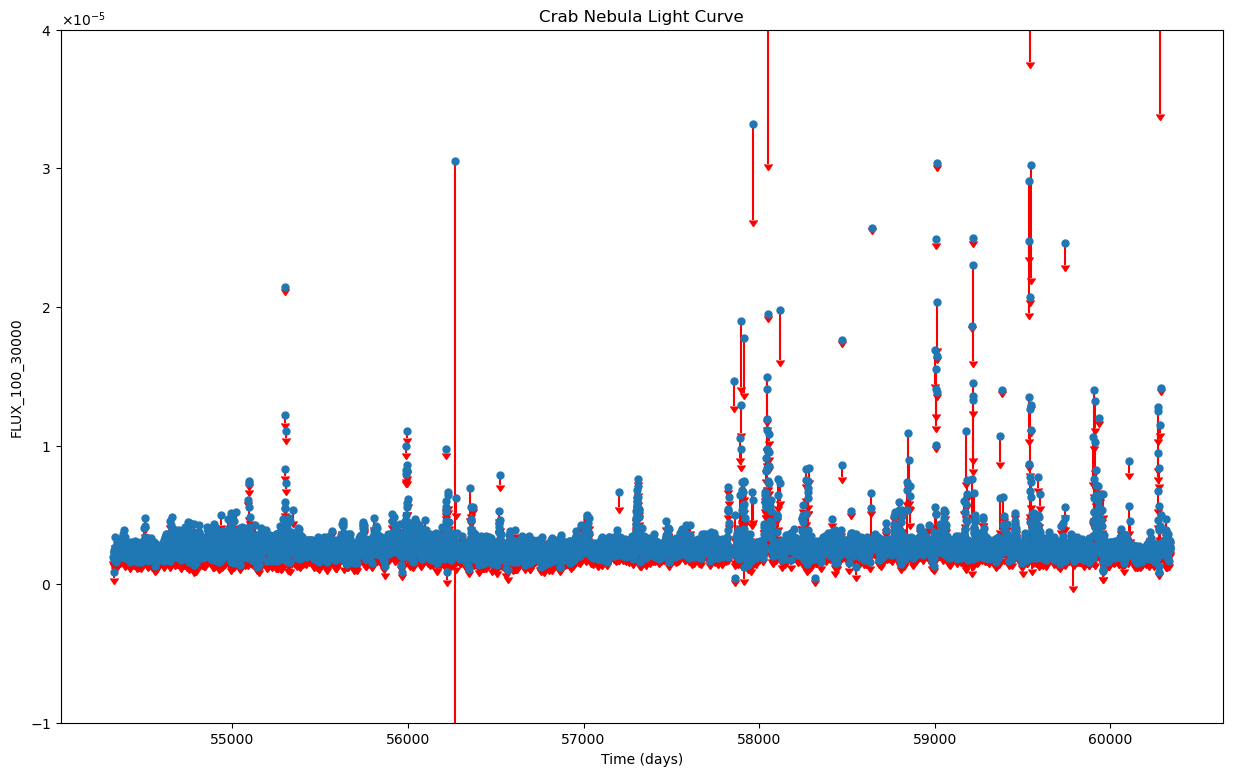

In [7]:
from matplotlib.ticker import ScalarFormatter

# adapting plot

# adjusting for mjd
mjd_offset = 51544
mjd_time = time + mjd_offset

plt.figure(figsize=(15, 9))
plt.errorbar(mjd_time, flux, yerr=flux_err, fmt='o', uplims=True, ecolor = 'red', markersize = 5)
plt.xlabel('Time (days)')
plt.ylabel('FLUX_100_30000')
plt.title('Crab Nebula Light Curve')

# Set y-axis to scientific notation
plt.gca().yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
plt.ticklabel_format(axis='y', style='sci', scilimits=(0,0))

# axes limits
plt.ylim(-0.00001, .00004)


plt.show()

### 2.d. Zooming in on a flare

Great! Now let's dive into this data set further. As from the reading, we know that the Crab Nebula flares in gamma-rays, and so we should be able to see flares in this data. Let's zoom into one of these flares in particular. There seems to be a flare around day 6500. Adapt your plot to visualize this flare.

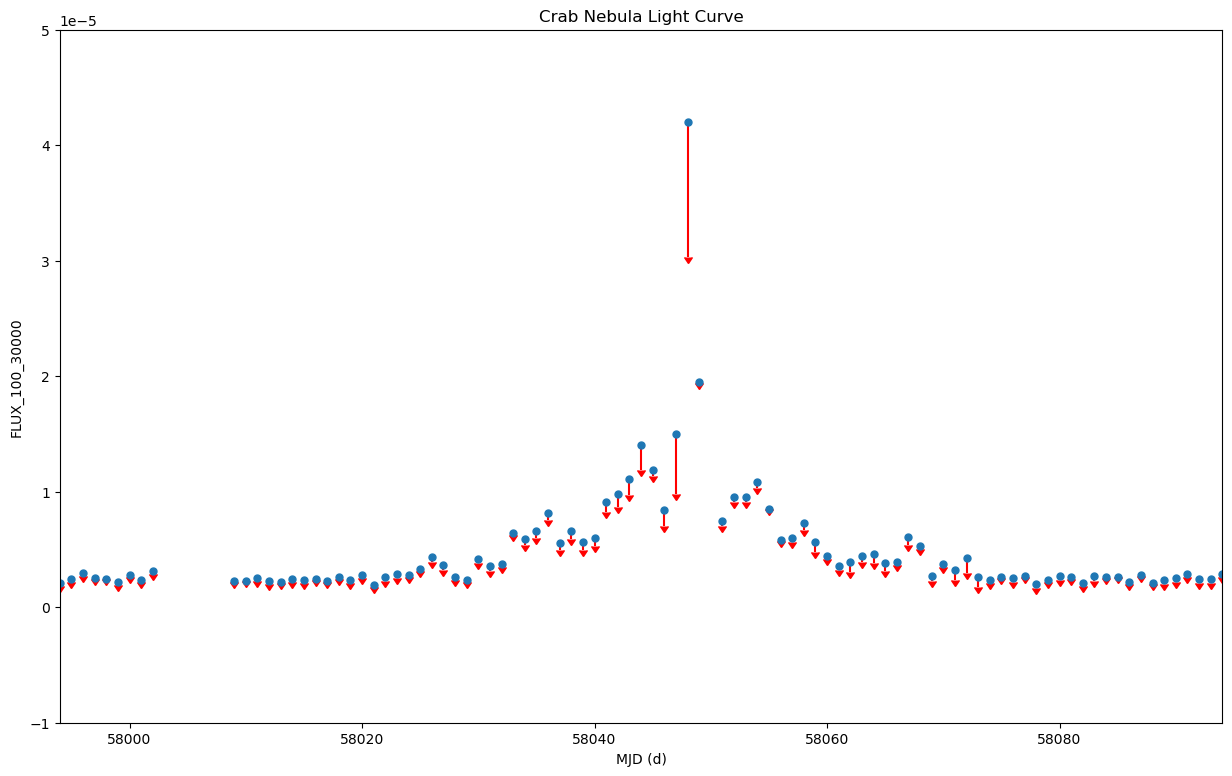

In [37]:
# Zooming in on the flare
plt.figure(figsize=(15, 9))
plt.errorbar(mjd_time, flux, yerr=flux_err, fmt='o', uplims=True, ecolor = 'red', markersize = 5)
plt.xlabel('MJD (d)')
plt.ylabel('FLUX_100_30000')
plt.title('Crab Nebula Light Curve')
plt.xlim(mjd_offset+6450, mjd_offset+6550)
plt.ylim(-0.00001, .00005)
plt.show()

Here we can see the flux of the Crab Nebula has increased an order of magnitude. Now let's try to fit some functions to this flare to find the time when the flare peaks.

# Question 3: Introduction to Functions

Just like the functions we have already used in this class (such as `plt.errorbar` or `print`), a function is a block of code which only runs when it is called. You can pass data, known as parameters, into a function. For example, the `print` function intakes a parameter, and does something to that parameter, in this case it prints that parameter to the screen: For example, `print("Hello")` intakes the parameter "Hello" and prints it to the screen. Here, we will be able to define our own functions that can intake different parameter(s) and do something to them. To define a new function, we use the following format:

`def function(parameters):
    perform a function
    return output`
    
So for example, let me define a function (that I will call add5) that will add 5 to a number x I input:

In [9]:
def add5(x):
    result = x + 5
    return result

Now that we have defined this function, we can call it in our script to use it. So for example, if I wanted to add 5 to a number, let's say 7, I would call the function by doing the following and running it:

In [10]:
add5(7)

12

And look at that! Our function has taken our input (7) and added 5 to it, and returned the result (12). Functions can be made very complex, and even have functions within them, but if you would like to learn more, please refer to this website: <url> https://www.datacamp.com/community/tutorials/functions-python-tutorial .

### 3.a. Create your own function

Create your own function (it can do anything!) and run it below.

In [11]:
# complicated AI function
def the_first_agi(x):
    if "meaning" and "life" in x:
        return "42"
    else:
        return "nah"

query = "Can you finish this programming assignment for me?"
print(query + "\n" + the_first_agi(query))

query = "What is the meaning of life?"
print(query + "\n" + the_first_agi(query))

Can you finish this programming assignment for me?
nah
What is the meaning of life?
42


# Question 4: Using Functions to fit our data

Now let's take what we've learned about python function to help us fit our flare. One of the best first-pass flare fitting functions is the Gaussian function. Let's make a python Gaussian function. Below, I have defined a python function that computes the gaussian for our input x-array (x), where we define the parameters of our gaussian with a height `a`, a position `b`, and a standard deviation `c`:

In [12]:
def gauss(x, a, b, c):
    return a * np.exp(-(x-b)**2/(2*c**2))

### 4.a. Fit your data to a Gaussian and plot


Now that we have defined a function that we want to fit our data to, let's talk about how exactly we get our code to fit the data: meaning, what are the best a, b, and c parameters that best fit our data when we input our flare light curve. To do so, look up the documentation for the `curve_fit` function from the `scipy.optimize` module (you will need to import it first). 
* First, select from the data the time frame you want to fit. Make new arrays that contain just these data.
* Next, use the documentation and the examples provided in this documentation to fit your selected data to the Gaussian function. It is usually a good idea to give an intial guess for the parameters. 
* Once you have fit the data, plot this fit and the data to qualitatively see how well the fit is.

In [53]:
# Importing necessary libraries
from scipy.optimize import curve_fit

# Select the flare data to fit
mask = (mjd_time > 6450 + mjd_offset) & (mjd_time < 6550 + mjd_offset)
time_fit = mjd_time[mask]
flux_fit = flux[mask]
flux_err_fit = flux_err[mask]

# Fitting the data
popt, pcov = curve_fit(gauss, time_fit, flux_fit, p0=[2, 6505 + mjd_offset, 20])

# Generate dense time points for smooth plotting
time_smooth = np.linspace(time_fit.min(), time_fit.max(), 500)  # 500 points for smoothness
flux_smooth = gauss(time_smooth, *popt)

# print fitted parameters
print("Fitted parameters (amplitude, mean, sigma):", popt)
print(popt[1])

Fitted parameters (amplitude, mean, sigma): [1.33656592e-05 5.80475808e+04 1.08669111e+01]
58047.5808315655


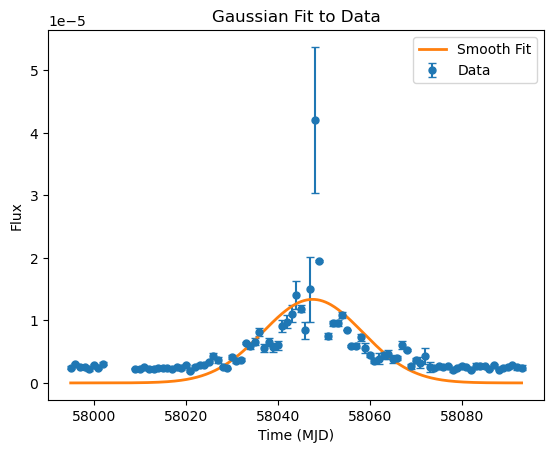

Fitted parameters (amplitude, mean, sigma): [1.33656591e-05 5.80475808e+04 1.08669111e+01]


In [52]:
# Plot original data and smooth fit
plt.errorbar(time_fit, flux_fit, yerr=flux_err_fit, fmt='o', label='Data', markersize=5, capsize=3)
plt.plot(time_smooth, flux_smooth, '-', label='Smooth Fit', linewidth=2)
plt.xlabel('Time (MJD)')
plt.ylabel('Flux')
plt.legend()
plt.title('Gaussian Fit to Data')
plt.show()

# Print the fitted parameters
print("Fitted parameters (amplitude, mean, sigma):", popt)

### 4.b. Reflecting on the Gaussian fit


Here we have fit our first data set from an archive! Does this look like a good fit? How could we improve the fit? When is the fitted peak of this flare (the fitted 'b' parameter)?  

<span style="color:blue">
    The fit looks pretty good, but it looks like its missing some higher points. The point at the very top does have quite a high error, but maybe the fit could be improved if it took these points into account. perhaps a different fitting method could help? The fitted peak of the flare is at MJD 58047.58.
</span>

### 4.c. Fitting Data to a 2-D Polynomial

Gaussian functions are a great first stepping stone, but let's now try to fit a second degree polynomial to our data. To do this we will use the `polyfit` (which you can use to fit a polynomial to your data) and `poly1d` (which you can use to calculate the polynomial function after fitting) functions. These are supplied in the `numpy` module. Please use the documentation to fit your flare to a second degree polynomial. Then, plot this fit with the flare data.

In [55]:
# Fit 2nd-degree polynomial to the same data
coefficients_poly = np.polyfit(time_fit, flux_fit, 2)
poly_function = np.poly1d(coefficients_poly)

flux_poly = poly_function(time_fit)

### 4.d. Comparing your fits

Now plot both your Gaussian fit and your second degree polynomial fit on top of one another. 

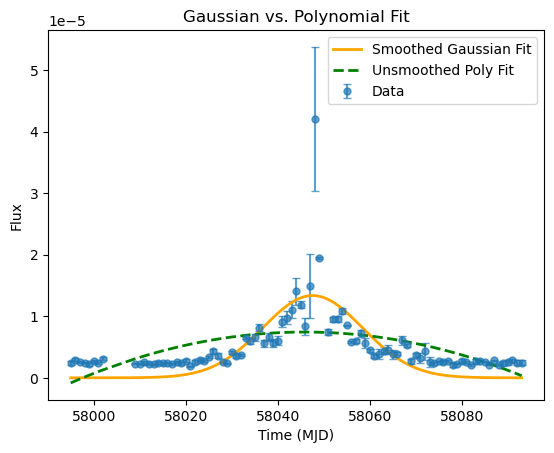

In [57]:
# Plot everything
plt.errorbar(time_fit, flux_fit, yerr=flux_err_fit, fmt='o', label='Data', markersize=5, capsize=3, alpha=0.7)
plt.plot(time_smooth, flux_smooth, '-', label='Smoothed Gaussian Fit', linewidth=2, color='orange')
plt.plot(time_fit, flux_poly, '--', label='Unsmoothed Poly Fit', linewidth=2, color='green')

plt.xlabel('Time (MJD)')
plt.ylabel('Flux')
plt.legend()
plt.title('Gaussian vs. Polynomial Fit')
plt.show()

# Question 5: Residuals

### 5.a. Plotting the residual

One way to determine which fitting algorithm fit our data the best is to determine residuals: the difference between our data and the fit. That is,
$$ residual = y_{observed}-y_{model} $$
Compute the residuals for both fits and plot them (make sure to label which curve corresponds to which fit). 

In [59]:
# gaussian residuals
residual_gauss = flux_fit - gauss(time_fit, *popt)

# polynomial residuals
residual_poly = flux_fit - poly_function(time_fit)

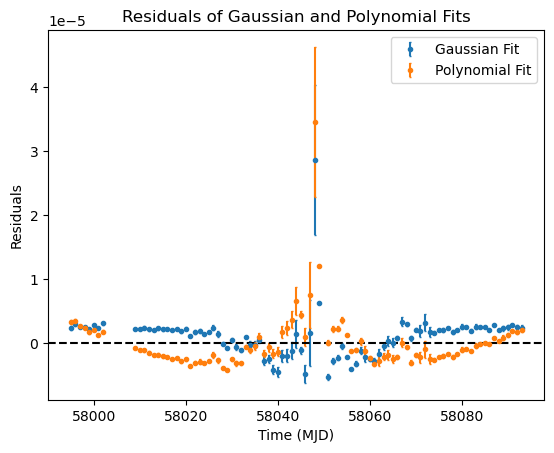

In [64]:
# plotting both residuals on the same plot

plt.errorbar(time_fit, residual_gauss, yerr=flux_err_fit, fmt='o', label='Gaussian Fit', markersize=3, capsize=1)
plt.errorbar(time_fit, residual_poly, yerr=flux_err_fit, fmt='o', label='Polynomial Fit', markersize=3, capsize=1)

# adding 0 line
plt.axhline(0, color='black', linestyle='--')

plt.xlabel('Time (MJD)')
plt.ylabel('Residuals')
plt.legend()
plt.title('Residuals of Gaussian and Polynomial Fits')
plt.show()

### 5.b. Calculating the RMSE (residual mean square error)

We can also calculate a single number that reflects the residuals, which is the RMSE. The RMSE is defined as:

$$\sqrt{ \frac1N \sum{ (y_{observed}-y_{model})^2 } }$$

Where $N$ is the total number of data points that were used in the fit. Note that the residuals you calculated in the previous part appear in this equation, and that they are squared before they are summed together. Compute the RMSE for both fits and print out the values.

In [65]:
# calculating RMSE for the residuals
rmse_gauss = np.sqrt(np.mean(residual_gauss**2))
rmse_poly = np.sqrt(np.mean(residual_poly**2))

print("RMSE for Gaussian fit:", rmse_gauss)
print("RMSE for Polynomial fit:", rmse_poly)

RMSE for Gaussian fit: 3.8130767966530866e-06
RMSE for Polynomial fit: 4.481594569985477e-06


### 5.c. Comment on your results

Considering the fits qualitatively (i.e. the plots you made) and quantitatively (i.e. the RMSE), which of the fits would you use? If you were doing this for your research project, what next steps might you take? (No right answers!)

<span style="color:blue">
    While the gaussian fit looks like its "missing" some points/not accounting for them, it is much better at fitting the pulse than the polynomial fit. Not only does the plot visually look more similar to the pulse's signature, the residuals are also closer to the zero line. The RMSE for the gaussian fit is also lower than the polynomial fit, which suggests that the gaussian fit is better. There is, however, an obvious trend for both residuals, so neither fitting method is perfect. Despite this, in their current states, I would use the gaussian fit. For my research project, I would try to use some more fitting methods to see if I could get a better fit. I could also try changing the parameters of the gaussian fit to see if I could get a better fit.
</span>